<a href="https://colab.research.google.com/github/kaveesha82/DS_Project/blob/component-1/arrival_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_excel('/content/drive/MyDrive/DSGP/monthlyarrivals.xlsx')

In [ ]:
#Clean column names
df.columns = df.columns.str.strip()

#Remove commas inside numbers
df = df.replace(",", "", regex=True)


df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1452 entries, 0 to 1451
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Year         1452 non-null   int64  
 1   Month        1452 non-null   object 
 2   Nationality  1452 non-null   object 
 3   Arrivals     1452 non-null   int64  
 4   Avg_Stay     1056 non-null   float64
 5   Revenue_USD  1056 non-null   float64
dtypes: float64(2), int64(2), object(2)
memory usage: 68.2+ KB


In [ ]:
df.shape


(1452, 6)

In [ ]:
df.columns

Index(['Year', 'Month', 'Nationality', 'Arrivals', 'Avg_Stay', 'Revenue_USD'], dtype='object')

In [ ]:
df.dtypes

,0
Year,int64
Month,object
Nationality,object
Arrivals,int64
Avg_Stay,float64
Revenue_USD,float64


In [ ]:
df.isnull().sum()

,0
Year,0
Month,0
Nationality,0
Arrivals,0
Avg_Stay,396
Revenue_USD,396


In [ ]:
#Encode months
month_map = {
    "January":1, "February":2, "March":3, "April":4,
    "May":5, "June":6, "July":7, "August":8,
    "September":9, "October":10, "November":11, "December":12
}

df["Month_Num"] = df["Month"].map(month_map)

In [ ]:
df.head()

,Year,Month,Nationality,Arrivals,Avg_Stay,Revenue_USD,Month_Num
0,2025,January,India,45496,6.8,58310242.0,1
1,2025,January,Russian Federation,37914,12.5,89335013.0,1
2,2025,January,United Kingdom,20220,13.2,50311716.0,1
3,2025,January,Germany,17693,14.2,47358358.0,1
4,2025,January,China,15165,8.5,24300108.0,1


In [ ]:
df = df.sort_values(["Nationality", "Year", "Month_Num"])

In [ ]:
df["Date"] = pd.to_datetime(
    df["Year"].astype(str) + "-" + df["Month_Num"].astype(str) + "-01"
)


In [ ]:
df["Month_Name"] = df["Date"].dt.month_name()

seasonality = (
    df.groupby(["Nationality", "Month_Name"])["Arrivals"]
      .mean()
      .reset_index()
)


In [ ]:
peak_months = (
    seasonality
    .sort_values(["Nationality", "Arrivals"], ascending=False)
    .groupby("Nationality")
    .first()
)

peak_months


,Month_Name,Arrivals
Nationality,,
Australia,December,9064.272727
Bangladesh,May,7975.000000
Belarus,February,44.000000
Canada,July,3852.166667
China,February,18255.000000
France,February,10789.700000
Germany,February,12495.545455
India,December,36736.181818
Iran,March,3738.000000


In [ ]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error
import numpy as np

results_list = []
forecasts = {}

for nat in df["Nationality"].unique():
    series = df[df["Nationality"]==nat].set_index("Date")["Arrivals"]

    #12 months for testing,24 for training
    if len(series) < 36:
        print(f"Skipping {nat} — not enough data")
        continue

    train = series[:-12]
    test = series[-12:]

    # Holt-Winters
    hw = ExponentialSmoothing(
        train, trend="add", seasonal="add", seasonal_periods=12
    ).fit()
    hw_pred = hw.forecast(12)
    hw_rmse = np.sqrt(mean_squared_error(test, hw_pred))

    # SARIMA
    sarima = SARIMAX(
        train, order=(1,1,1), seasonal_order=(1,1,1,12),
        enforce_stationarity=False, enforce_invertibility=False
    ).fit(disp=False)
    sarima_pred = sarima.forecast(12)
    sarima_rmse = np.sqrt(mean_squared_error(test, sarima_pred))

    # Store results
    best_model = "SARIMA" if sarima_rmse < hw_rmse else "Holt-Winters"
    results_list.append({
        "Nationality": nat,
        "HW_RMSE": hw_rmse,
        "SARIMA_RMSE": sarima_rmse,
        "Best_Model": best_model
    })
    forecasts[nat] = {"HW": hw_pred, "SARIMA": sarima_pred}


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/

Skipping Bangladesh — not enough data
Skipping Belarus — not enough data


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/

Skipping Iran — not enough data
Skipping Israel — not enough data
Skipping Italy — not enough data
Skipping Japan — not enough data
Skipping Kazakhastan — not enough data
Skipping Kazakhstan — not enough data


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/py

...

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/

Skipping Ukraine — not enough data


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/stat

Skipping United states — not enough data
Skipping canada — not enough data
Skipping china — not enough data
Skipping france — not enough data
Skipping india — not enough data
Skipping others — not enough data
Skipping spain — not enough data
Skipping ukraine — not enough data
Skipping united states — not enough data


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [ ]:
results_df = pd.DataFrame(results_list)
results_df.sort_values("SARIMA_RMSE")


,Nationality,HW_RMSE,SARIMA_RMSE,Best_Model
12,USA,1306.382594,1026.215328,SARIMA
1,Canada,1191.315251,1183.873319,SARIMA
14,United States,8259.325271,1714.580381,SARIMA
0,Australia,2178.136111,1928.293078,SARIMA
3,France,4186.554073,2785.162008,SARIMA
4,Germany,2663.196740,3367.678750,Holt-Winters
6,Maldives,2847.543619,3488.487151,Holt-Winters
11,UK,4493.597798,4998.461254,Holt-Winters
2,China,8529.244389,5394.704119,SARIMA
13,United Kingdom,6123.656904,5450.558844,SARIMA


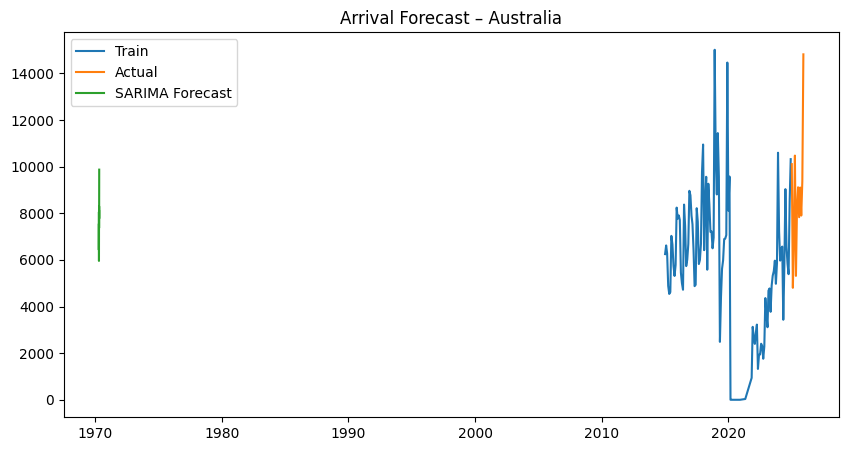

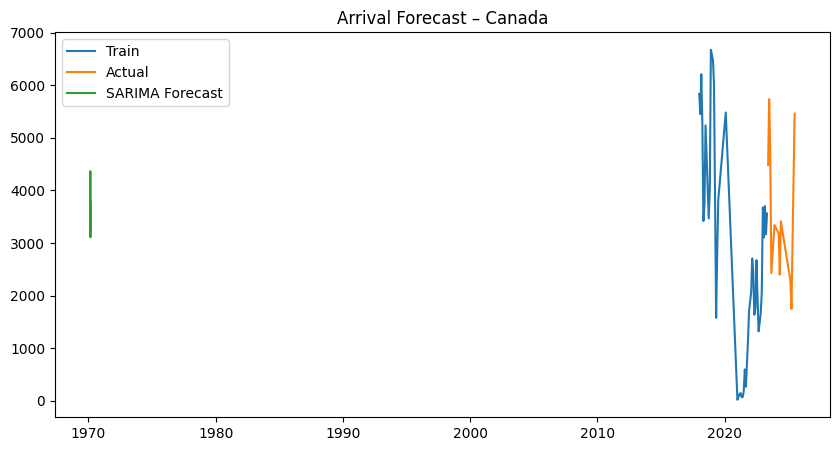

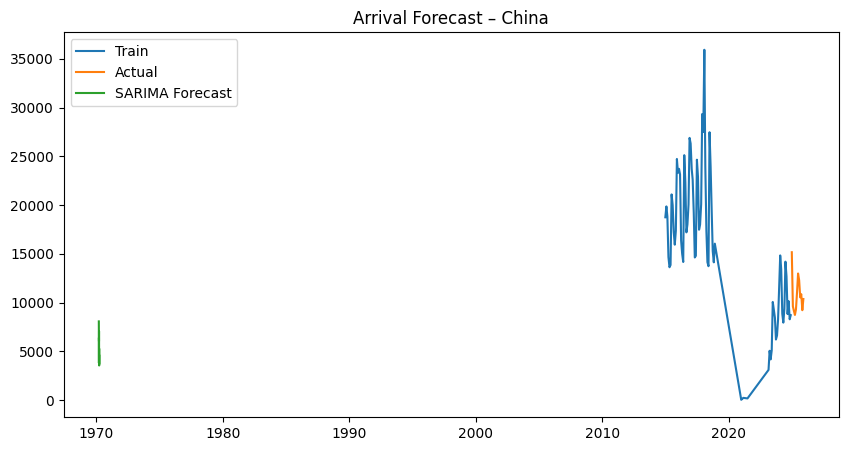

In [ ]:
import matplotlib.pyplot as plt

top_nationalities = results_df["Nationality"].head(3)

for nat in top_nationalities:
    series = (
        df[df["Nationality"] == nat]
        .set_index("Date")["Arrivals"]
    )

    train = series[:-12]
    test = series[-12:]

    plt.figure(figsize=(10,5))
    plt.plot(train, label="Train")
    plt.plot(test, label="Actual")
    plt.plot(forecasts[nat]["SARIMA"], label="SARIMA Forecast")
    plt.title(f"Arrival Forecast – {nat}")
    plt.legend()
    plt.show()

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
# COVID dummy variable
df["COVID_Dummy"] = 0
df.loc[
    (df["Date"] >= "2020-03-01") & (df["Date"] <= "2021-12-01"),
    "COVID_Dummy"
] = 1

results_list = []
forecasts = {}

for nat in df["Nationality"].unique():

    temp = df[df["Nationality"] == nat].set_index("Date")
    y = temp["Arrivals"]
    exog = temp[["COVID_Dummy"]]

    # Ensure enough data
    if len(y) < 36:
        print(f"Skipping {nat} — not enough data")
        continue

    # Train-test split
    y_train = y[:-12]
    y_test = y[-12:]

    exog_train = exog[:-12]
    exog_test = exog[-12:]

    # SARIMAX model
    model = SARIMAX(
        y_train,
        exog=exog_train,
        order=(1,1,1),
        seasonal_order=(1,1,1,12),
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    fit = model.fit(disp=False)

    # Forecast
    forecast = fit.forecast(12, exog=exog_test)

    # Evaluation
    rmse = np.sqrt(mean_squared_error(y_test, forecast))

    # Store results
    results_list.append({
        "Nationality": nat,
        "SARIMAX_RMSE": rmse,
        "COVID_Coefficient": fit.params["COVID_Dummy"]
    })

    forecasts[nat] = forecast

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
/

Skipping Bangladesh — not enough data
Skipping Belarus — not enough data


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dis

Skipping Iran — not enough data
Skipping Israel — not enough data
Skipping Italy — not enough data
Skipping Japan — not enough data
Skipping Kazakhastan — not enough data
Skipping Kazakhstan — not enough data


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/

...

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
/

Skipping Ukraine — not enough data


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/

Skipping United states — not enough data
Skipping canada — not enough data
Skipping china — not enough data
Skipping france — not enough data
Skipping india — not enough data
Skipping others — not enough data
Skipping spain — not enough data
Skipping ukraine — not enough data
Skipping united states — not enough data


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [ ]:
results_df = pd.DataFrame(results_list)
results_df.sort_values("SARIMAX_RMSE")


,Nationality,SARIMAX_RMSE,COVID_Coefficient
12,USA,1026.215328,0.000000
1,Canada,1541.421642,-3045.639987
0,Australia,2045.607361,-5920.221923
4,Germany,2240.564600,-7686.999976
3,France,2399.447439,-5375.249839
13,United Kingdom,3224.723092,-12368.248353
6,Maldives,3665.041451,-6805.331838
11,UK,4998.461254,0.000000
2,China,5188.990388,-10269.750186
5,India,6839.091212,-13654.000049
